## Simple thermal model
This notebook has a demonstration of how to use the `ThermalModel` class (see `thermal_model.py`) to get pulses in a TES by modelling the heat flow across components

In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.insert(0, '..')
from thermal_model import *
import copy
import random as rdm
import yaml
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy import integrate
%matplotlib inline
from scipy.signal import deconvolve
import json
import csv
plt.style.use("../scdmssty.mplstyle")

In [2]:
### Load in the settings file from the NEXUS group for convenience
with open("mod_nexus.txt","r") as f:
    p = yaml.safe_load(f)

In [3]:
## Lets test a new setup just between a TES and the bath
### Lets start very simple just to see if all the connections are correct....
Tc = 40E-3
Tb = 25E-3
tes = TES(25E-3,50,1,Tc,0.5,150E-3,300E-9,Tc,p["Lte"],p["Ate"],C_dict([p["cte_1_05"],p["cte_3_05"]]))
bath = Component("bath",Tb,1,1,0) ## heat capacity of bath not used, set to 0
abs = Component("abs",Tb,p["La"],p["Aa"],C_dict([p["ca_1_05"],p["ca_3_05"]]))
abs.add_connection(bath,G_dict(p["G_ab_05"]*1E4,p["nab"]))
abs.add_connection(tes,G_dict(p["G_ab_05"]*1E-3,p["nab"]))
tes.add_connection(bath,G_dict(p["G_ab_05"]*1E3,p["nab"]))

model = ThermalModel([tes,bath,abs])

Calculating temperatures for equilibrium:
TES temp: 0.04 K
bath temp: 0.025 K
abs temp: 0.02500000347099893 K
setting current to 3.97208118280301e-07 A


In [4]:
eV_to_J = 1.60218e-19
def event(t):
    #return 0
    if t>(0.5E-2 + 9E-6 )and t<(0.5E-2 + 1.1E-5):
        return 1E-6#*eV_to_J
    else:
        return 0

dt = 1E-7
# t_s = np.arange(0,2.99E-5,dt)
t_s = np.arange(0,5E-2,dt)

ev = []
tes_i= []
tes_t = []
tes_p = []
tes_pt = []
tes_r = []
tes_totp = []
temps = {c:[] for c in model.components}

model.reset_model()
tes = model.components["TES"]

for t in t_s:
    ev.append(event(t)/eV_to_J)
    # tes.T += event(t)*(dt/tes.C()) + tes.dT_TES(dt) 
    # tes.I += tes.dI(dt)
    model.step(event,dt)
    tes_i.append(tes.I)
    tes_t.append(tes.T)
    tes_p.append(tes.P_J())
    tes_pt.append(tes.dT(dt)*tes.C()/dt)
    tes_totp.append(tes_p[-1] +tes_pt[-1])
    tes_r.append(tes.R())
    for c in model.components:
        temps[c].append(model.components[c].T)


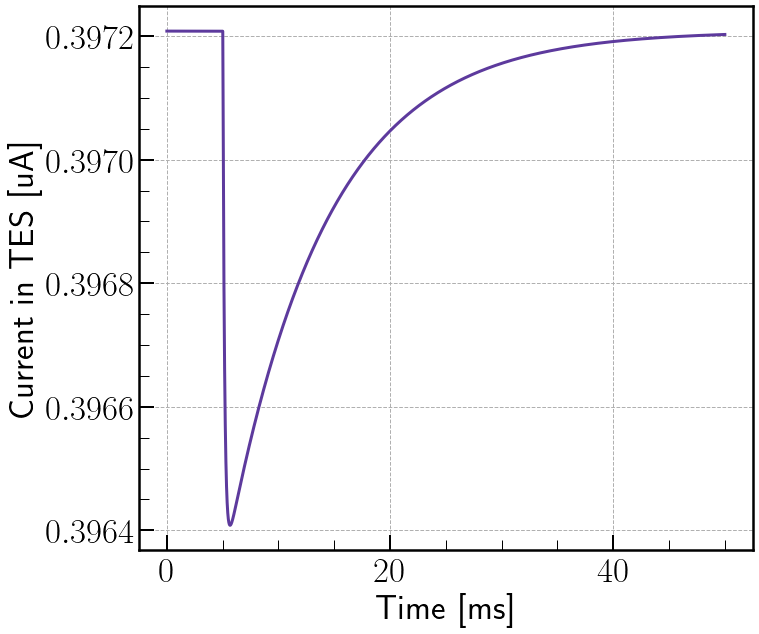

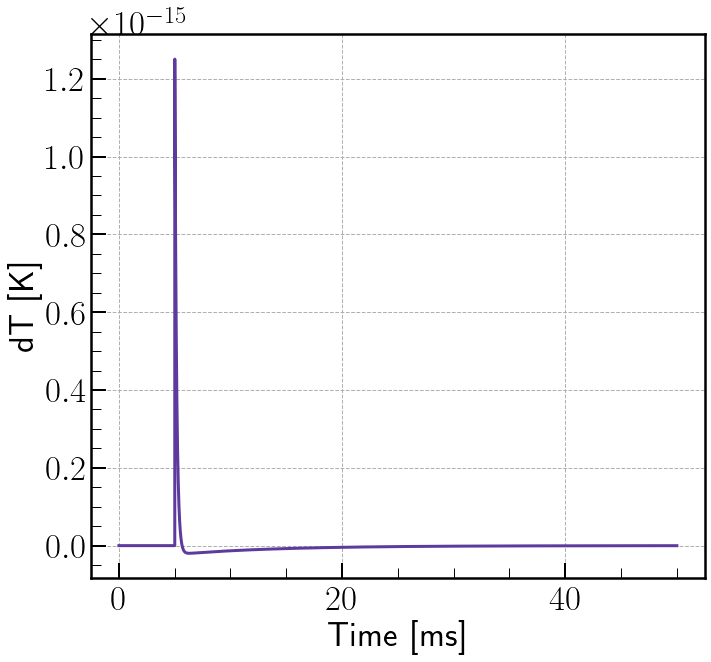

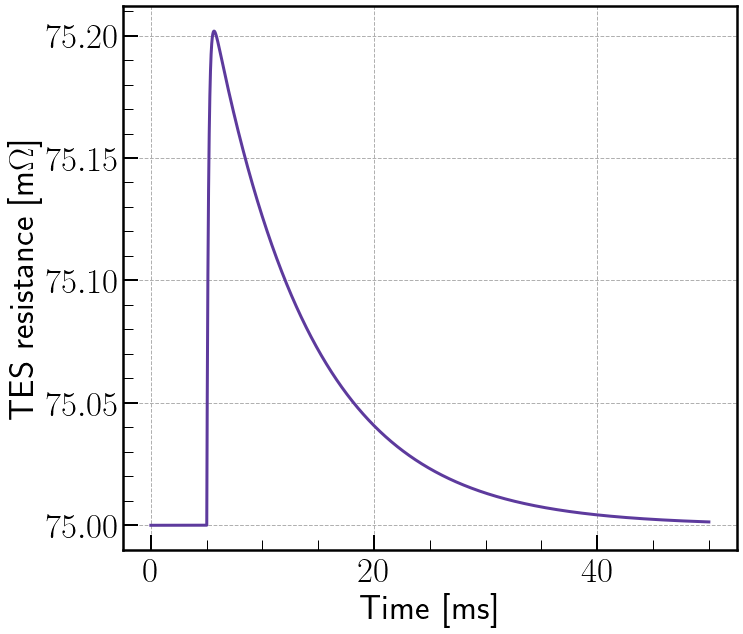

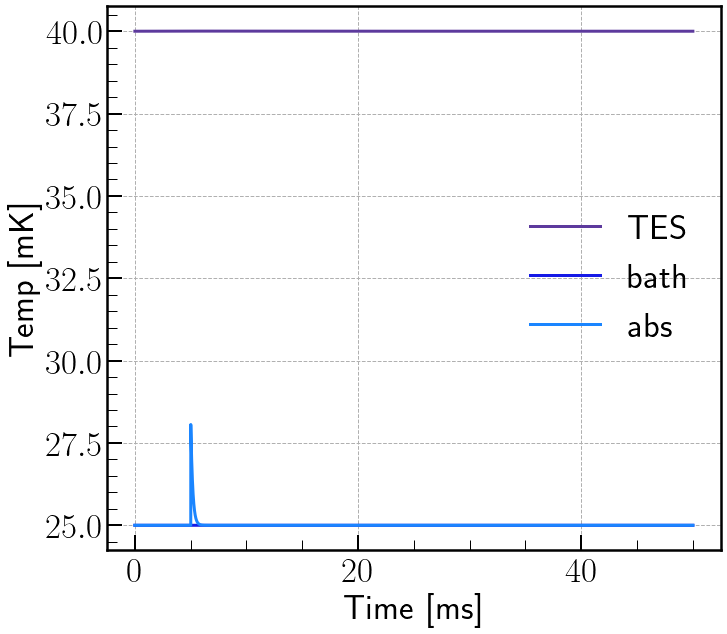

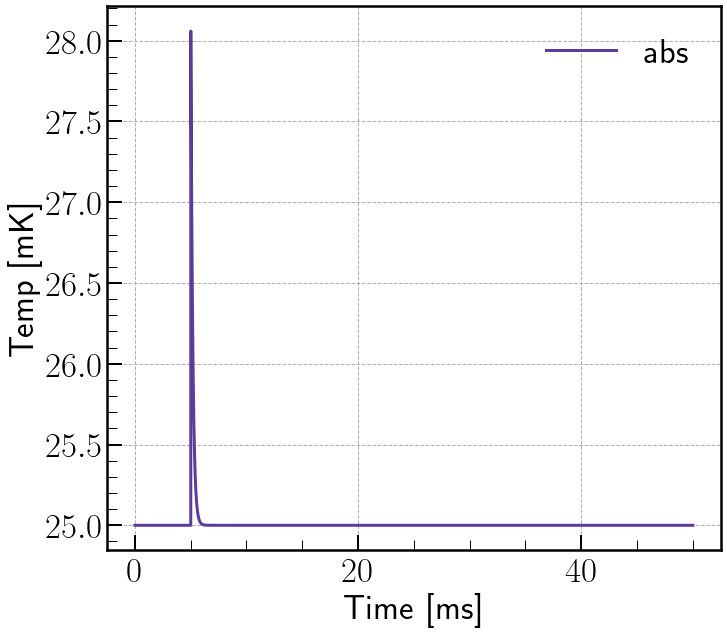

In [5]:
plt.plot(t_s*1E3,[i*1E6 for i in tes_i])
plt.ylabel("Current in TES [uA]")
plt.xlabel("Time [ms]")
plt.show()

plt.plot(t_s*1E3,tes_totp)
plt.ylabel("dT [K]")
plt.xlabel("Time [ms]")
plt.show()

plt.plot(t_s*1E3,[r*1E3 for r in tes_r])
plt.ylabel(r"TES resistance [m$\Omega$]")
plt.xlabel("Time [ms]")
plt.show()

for c in temps:
    plt.plot(t_s*1E3,[t*1E3 for t in temps[c]],label=c)
plt.ylabel("Temp [mK]")
plt.xlabel("Time [ms]")
plt.legend()
plt.show()

plt.plot(t_s*1E3,[t*1E3 for t in temps["abs"]],label=c)
plt.ylabel("Temp [mK]")
plt.xlabel("Time [ms]")
plt.legend()
plt.show()
